In [66]:
# Import library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler

In [67]:
#2 Load dataset
train_df = pd.read_csv('emnist-letters-train.csv')

# Pisahkan label & pixel format df.iloc[baris, kolom]
labels = train_df.iloc[:,0].values        # shape: (n_samples,)
images = train_df.iloc[:,1:].values       # shape: (n_samples, 784)

In [68]:
print("Jumlah sample:", labels.shape[0])

Jumlah sample: 88799


In [69]:
print("Dimensi pixel per sample:", images.shape[1])

Dimensi pixel per sample: 784


In [70]:
train_df

,23,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.406,0.407,0.408,0.409,0.410,0.411,0.412,0.413,0.414,0.415
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,16,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,15,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,23,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,17,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88794,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
88795,21,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
88796,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
88797,23,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [71]:
#3 membagi sample per letter sebanyak 100, sehingga total ada 2,6K sample dari 88.8k sample

# format df.iloc[baris, kolom] dan simpan list kecil untuk tiap label
samples_per_class = 100
sampled_df = pd.DataFrame()

for label in range(1, 27):  # 1=A, 2=B, ..., 26=Z
    subset = train_df[train_df.iloc[:,0] == label]
    sampled = subset.sample(n=samples_per_class, random_state=42)
    sampled_df = pd.concat([sampled_df, sampled])

In [72]:
# cek
print(sampled_df.shape)  # harus (2600, 785)

(2600, 785)


In [73]:
sampled_df.shape[0]

2600

In [74]:
#4 Ambil labels & images dari 13K sampel hasil sampling
labels_sampled = sampled_df.iloc[:, 0].values
images_sampled = sampled_df.iloc[:, 1:].values

In [75]:
labels_sampled.shape

(2600,)

In [76]:
images_sampled.shape

(2600, 784)

In [77]:
#5 Ekstrak HOG feature dari 2,6k data yang tadi

hog_features = []

for i in range(len(images_sampled)):
    img = images_sampled[i].reshape(28,28)  # reshape 1D → 2D per gambar
    feature = hog(img, orientations=9, pixels_per_cell=(8,8),
                  cells_per_block=(2,2), block_norm='L2-Hys')
    hog_features.append(feature)

hog_features = np.array(hog_features)

In [78]:
print(hog_features.shape)

(2600, 144)


In [79]:
# Rescale hog feature

# === RESCALE FITUR ===
scaler = StandardScaler()
X = scaler.fit_transform(hog_features)
y = labels_sampled

In [80]:
#6 Mempersiapkan data untuk SVM kernel RBF

X = hog_features         # shape: (2600, 144)
y = labels_sampled       # shape: (2600,)

svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

In [81]:
# setting batch
batch_size = 100
n_samples = X.shape[0]
save_file = "y_results_partial_RBF.csv"

In [82]:
# resume checkpoint jika ada batch
try:
    df = pd.read_csv(save_file)
    start_index = len(df)  # mulai dari baris berikutnya
    y_true_all = df["y_true"].tolist()
    y_pred_all = df["y_pred"].tolist()
    print(f"Resuming from sample index {start_index}")
except FileNotFoundError:
    start_index = 0
    y_true_all = []
    y_pred_all = []
    print("Starting from scratch")

Resuming from sample index 2600


In [83]:
from tqdm import tqdm

In [84]:
cv = LeaveOneOut()
splits = list(cv.split(X))  # buat index dulu biar bisa resume

for i in tqdm(range(start_index, len(splits)), total=len(splits), initial=start_index, desc="LOOCV Progress"):
    train_ix, test_ix = splits[i]
    X_train, X_test = X[train_ix, :], X[test_ix, :]
    y_train, y_test = y[train_ix], y[test_ix]

    svm_clf.fit(X_train, y_train)
    y_pred = svm_clf.predict(X_test)

    y_true_all.append(y_test[0])
    y_pred_all.append(y_pred[0])

    # checkpoint tiap 100 iterasi
    if (i+1) % 100 == 0:
        pd.DataFrame({"y_true": y_true_all, "y_pred": y_pred_all}).to_csv(save_file, index=False)

LOOCV Progress: 100%|██████████| 2600/2600 [00:00<?, ?it/s]


In [85]:
# mengambil data y hasil LOOCV

y_true = y_true_all
y_pred = y_pred_all

In [86]:
#8 Menampilkan Confusion Matix, ACC, PREC, F1
conf_matrix = confusion_matrix(y_true, y_pred)

In [87]:
conf_matrix

array([[70,  1,  1,  0,  3,  0,  2,  2,  0,  0,  0,  0,  2,  2,  0,  0,
        12,  1,  0,  1,  2,  0,  0,  0,  0,  1],
       [ 0, 75,  1,  0,  3,  0,  2, 10,  0,  1,  1,  0,  0,  1,  2,  0,
         2,  1,  0,  0,  1,  0,  0,  0,  0,  0],
       [ 2,  0, 76,  0, 12,  1,  3,  0,  1,  0,  0,  2,  0,  0,  0,  0,
         2,  0,  1,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  2,  0, 86,  0,  0,  0,  3,  0,  2,  0,  0,  0,  1,  3,  0,
         0,  0,  0,  2,  0,  0,  0,  0,  0,  0],
       [ 0,  4,  5,  0, 75,  4,  3,  0,  0,  1,  0,  0,  0,  0,  2,  1,
         3,  0,  0,  0,  0,  0,  0,  0,  0,  2],
       [ 0,  1,  0,  0,  0, 80,  1,  0,  0,  1,  0,  2,  0,  0,  0,  4,
         2,  2,  0,  6,  0,  0,  0,  0,  0,  1],
       [ 2,  4,  1,  0,  2,  1, 56,  0,  1,  1,  0,  0,  0,  0,  0,  0,
        25,  5,  2,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  5,  0,  2,  1,  0,  0, 75,  2,  0,  0,  3,  3,  2,  0,  1,
         0,  0,  0,  1,  3,  0,  0,  0,  0,  1],
       [ 0,  1,  0,  0,  0,  0, 

In [88]:
from mlxtend.plotting import plot_confusion_matrix

In [89]:
class_names = [chr(i) for i in range(65, 91)]  # A-Z

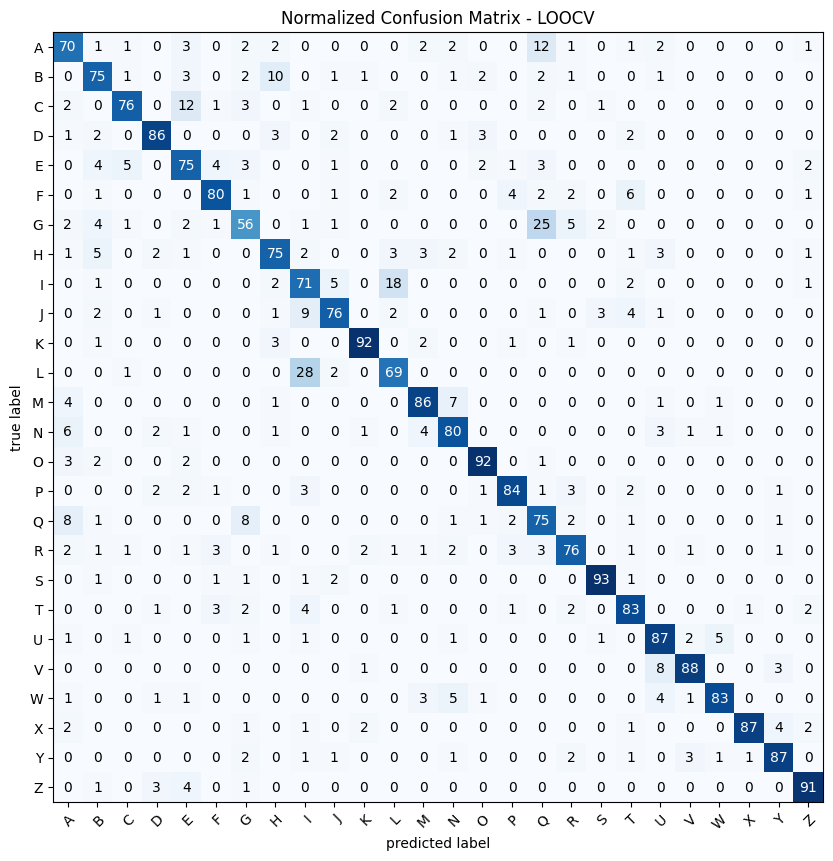

In [90]:
fig, ax = plot_confusion_matrix(conf_mat=conf_matrix, class_names=class_names, figsize=(12,10))

plt.title("Normalized Confusion Matrix - LOOCV")
plt.show()

In [91]:
#9 Menampilkan Accuracy
accuracy = accuracy_score(y_true, y_pred)

In [92]:
accuracy

0.805

In [93]:
#10 Menampilkan Presisi
precision = precision_score(y_true, y_pred, average= 'macro')

In [94]:
precision

0.8108374510469586

In [95]:
#11 Menampilkan F1 Score
f1 = f1_score(y_true, y_pred, average='macro')

In [96]:
f1

0.8064475337077979